# 💳 Week 2: EDA & Data Understanding — Credit Card Fraud Detection

**Dataset:** Credit Card Fraud Detection Dataset 2023  
**Source:** Kaggle — nelgiriyewithana/credit-card-fraud-detection-dataset-2023  
**Shape:** 568,630 rows × 31 columns  
**Objective:** Perform full Exploratory Data Analysis (EDA) to understand structure, quality, feature relationships, and domain relevance for ML/DL model preparation.

---
## 📌 Table of Contents
1. [Domain Context — Cybersecurity & Financial Fraud](#domain)
2. [Load the Dataset](#load)
3. [Exploratory Data Analysis](#eda)
4. [Visualizations](#viz)
5. [Data Quality Issues](#quality)
6. [Feature Relationships](#relationships)
7. [Document Findings](#findings)
8. [Data Profiling Report](#report)

---
## 1. 🌐 Domain Context — Cybersecurity & Financial Fraud <a id='domain'></a>

### What is Credit Card Fraud Detection?
Credit card fraud is a major cybersecurity and financial threat affecting millions of people worldwide. Fraudsters exploit stolen card details to make unauthorized transactions. **Machine learning models** are now the primary defense mechanism used by banks and payment processors to detect and block fraudulent transactions in real time.

### About This Dataset
This dataset contains **568,630 anonymized European credit card transactions** from 2023. For privacy protection, the original features have been transformed using **PCA (Principal Component Analysis)**, resulting in 28 anonymous components (V1–V28), plus the original `Amount` field.

| Feature | Description | Cybersecurity Relevance |
|---|---|---|
| `V1–V28` | PCA-transformed features | Encode behavioral patterns — unusual values may indicate fraud |
| `Amount` | Transaction amount in euros | Fraudulent transactions may show abnormal amounts |
| `Class` | 0 = Legitimate, 1 = Fraud | **Target variable** — binary classification |
| `id` | Transaction ID | Identifier only, not a predictive feature |

### Real-World Relevance
- Global credit card fraud losses exceed **\$32 billion annually**
- Banks use ML models trained on data like this to **block fraud in milliseconds**
- False negatives (missed fraud) cost money; false positives (blocking legit transactions) damage customer experience
- This makes **precision, recall, and F1-score** more meaningful than plain accuracy

### Key Challenge
The dataset is **highly imbalanced** — fraudulent transactions are a small minority. This is the most critical preprocessing challenge for building an effective ML/DL model.

In [ ]:
# ============================================================
# IMPORTS — All libraries for the full EDA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

FRAUD_COLOR  = '#e74c3c'
LEGIT_COLOR  = '#2ecc71'
PALETTE      = {0: LEGIT_COLOR, 1: FRAUD_COLOR}
LABEL_MAP    = {0: 'Legitimate', 1: 'Fraud'}

print('✅ All libraries imported successfully!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')

---
## 2. 📂 Load the Dataset <a id='load'></a>

In [2]:
# ============================================================
# TASK 1a — Load the dataset
# ============================================================
import pandas as pd
import numpy as np
df = pd.read_csv(
    '/kaggle/input/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/creditcard_2023.csv',
    low_memory=False
)

# Drop the id column — identifier only, not a feature
df.drop(columns=['id'], inplace=True)

print(f'✅ Dataset loaded successfully!')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

✅ Dataset loaded successfully!
   Shape: 568,630 rows × 30 columns
   Memory: 130.15 MB


In [3]:
# ============================================================
# TASK 1b — Structure, dimensions, and data types
# ============================================================

print('FIRST 5 ROWS:')
df.head()

FIRST 5 ROWS:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [4]:
print('LAST 5 ROWS:')
df.tail()

LAST 5 ROWS:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
568625,-0.833437,0.061886,-0.899794,0.904227,-1.002401,0.481454,-0.370393,0.189694,-0.938153,-1.161847,...,0.167503,0.419731,1.288249,-0.900861,0.560661,-0.006018,3.308968,0.081564,4394.16,1
568626,-0.670459,-0.202896,-0.068129,-0.267328,-0.133660,0.237148,-0.016935,-0.147733,0.483894,-0.210817,...,0.031874,0.388161,-0.154257,-0.846452,-0.153443,1.961398,-1.528642,1.704306,4653.40,1
568627,-0.311997,-0.004095,0.137526,-0.035893,-0.042291,0.121098,-0.070958,-0.019997,-0.122048,-0.144495,...,0.140788,0.536523,-0.211100,-0.448909,0.540073,-0.755836,-0.487540,-0.268741,23572.85,1
568628,0.636871,-0.516970,-0.300889,-0.144480,0.131042,-0.294148,0.580568,-0.207723,0.893527,-0.080078,...,-0.060381,-0.195609,-0.175488,-0.554643,-0.099669,-1.434931,-0.159269,-0.076251,10160.83,1
568629,-0.795144,0.433236,-0.649140,0.374732,-0.244976,-0.603493,-0.347613,-0.340814,0.253971,-0.513556,...,0.534853,-0.291514,0.157303,0.931030,-0.349423,-1.090974,-1.575113,0.722936,21493.92,1


In [5]:
# Full data type and non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      568630 non-null  float64
 1   V2      568630 non-null  float64
 2   V3      568630 non-null  float64
 3   V4      568630 non-null  float64
 4   V5      568630 non-null  float64
 5   V6      568630 non-null  float64
 6   V7      568630 non-null  float64
 7   V8      568630 non-null  float64
 8   V9      568630 non-null  float64
 9   V10     568630 non-null  float64
 10  V11     568630 non-null  float64
 11  V12     568630 non-null  float64
 12  V13     568630 non-null  float64
 13  V14     568630 non-null  float64
 14  V15     568630 non-null  float64
 15  V16     568630 non-null  float64
 16  V17     568630 non-null  float64
 17  V18     568630 non-null  float64
 18  V19     568630 non-null  float64
 19  V20     568630 non-null  float64
 20  V21     568630 non-null  float64
 21  V22     56

In [6]:
# Categorize columns by type
numeric_cols      = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols  = df.select_dtypes(include=['object']).columns.tolist()
feature_cols      = [c for c in numeric_cols if c != 'Class']
pca_features      = [c for c in feature_cols if c.startswith('V')]

print(f'Total columns       : {df.shape[1]}')
print(f'Numeric columns     : {len(numeric_cols)}')
print(f'Categorical columns : {len(categorical_cols)}')
print(f'PCA features (V1-V28): {len(pca_features)}')
print(f'Target column       : Class  (0=Legitimate, 1=Fraud)')

Total columns       : 30
Numeric columns     : 30
Categorical columns : 0
PCA features (V1-V28): 28
Target column       : Class  (0=Legitimate, 1=Fraud)


---
## 3. 📊 Exploratory Data Analysis <a id='eda'></a>
### 3a — Summary Statistics

In [7]:
# ============================================================
# TASK 2a — Summary statistics
# ============================================================

summary = df[feature_cols + ['Amount']].describe().T
summary['median']   = df[feature_cols].median()
summary['skewness'] = df[feature_cols].skew()
summary['kurtosis'] = df[feature_cols].kurtosis()
summary = summary[['count','mean','median','std','min','25%','50%','75%','max','skewness','kurtosis']]

print('NUMERICAL FEATURE SUMMARY STATISTICS')
print('=' * 80)
summary

NUMERICAL FEATURE SUMMARY STATISTICS


,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
V1,568630.0,-5.638058e-17,-0.093638,1.000001,-3.495584,-0.565286,-0.093638,0.832658,2.229046,-0.083417,-0.195511
V2,568630.0,-1.319545e-16,-0.135894,1.000001,-49.966572,-0.486678,-0.135894,0.343555,4.361865,-1.397952,54.506478
V3,568630.0,-3.518788e-17,0.000353,1.000001,-3.183760,-0.649299,0.000353,0.628538,14.125834,0.014622,0.288686
V4,568630.0,-2.879008e-17,-0.073762,1.000001,-4.951222,-0.656020,-0.073762,0.707005,3.201536,-0.044169,-0.103355
V5,568630.0,7.997245e-18,0.081088,1.000001,-9.952786,-0.293496,0.081088,0.439737,42.716891,1.506414,47.099352
V6,568630.0,-3.958636e-17,0.078718,1.000001,-21.111108,-0.445871,0.078718,0.497788,26.168402,-0.201611,4.490510
V7,568630.0,-3.198898e-17,0.233366,1.000001,-4.351839,-0.283533,0.233366,0.525955,217.873038,19.026866,4017.608217
V8,568630.0,2.109273e-17,-0.114524,1.000001,-10.756342,-0.192257,-0.114524,0.047299,5.958040,0.299972,18.939202
V9,568630.0,3.998623e-17,0.092526,1.000001,-3.751919,-0.568745,0.092526,0.559262,20.270062,0.171057,3.639324
V10,568630.0,1.991314e-16,0.262614,1.000001,-3.163276,-0.590101,0.262614,0.592460,31.722709,0.740414,13.164785


In [9]:
# Summary statistics split by Class
print('FEATURE MEANS: LEGITIMATE vs FRAUD')
print('=' * 60)

# Define the label mapping (adjust if your Class column uses different values)
LABEL_MAP = {0: 'Legitimate', 1: 'Fraud'}   # <-- This was missing!

# Create a readable label column
df['Class_Label'] = df['Class'].map(LABEL_MAP)

# Calculate mean of all feature columns grouped by class
mean_by_class = df.groupby('Class_Label')[feature_cols].mean().round(4)

mean_by_class

FEATURE MEANS: LEGITIMATE vs FRAUD


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class_Label,,,,,,,,,,,,,,,,,,,,,
Fraud,-0.5058,0.4919,-0.6821,0.736,-0.3386,-0.4351,-0.4912,0.1443,-0.5855,-0.6737,...,0.1799,0.1096,0.0141,0.0103,-0.1301,0.0618,0.0711,0.214,0.102,12057.6018
Legitimate,0.5058,-0.4919,0.6821,-0.736,0.3386,0.4351,0.4912,-0.1443,0.5855,0.6737,...,-0.1799,-0.1096,-0.0141,-0.0103,0.1301,-0.0618,-0.0711,-0.214,-0.102,12026.3135


In [10]:
# ============================================================
# TASK 2b — Class distribution and variability
# ============================================================

class_counts = df['Class'].value_counts()
class_pct    = (df['Class'].value_counts(normalize=True) * 100).round(4)

print('TARGET VARIABLE (Class) DISTRIBUTION')
print('=' * 40)
print(f'  Legitimate (0): {class_counts[0]:,}  ({class_pct[0]}%)')
print(f'  Fraud      (1): {class_counts[1]:,}   ({class_pct[1]}%)')
print(f'  Fraud ratio   : 1 fraud per every {int(class_counts[0]/class_counts[1])} legitimate transactions')

TARGET VARIABLE (Class) DISTRIBUTION
  Legitimate (0): 284,315  (50.0%)
  Fraud      (1): 284,315   (50.0%)
  Fraud ratio   : 1 fraud per every 1 legitimate transactions


In [11]:
# Amount feature analysis
print('TRANSACTION AMOUNT ANALYSIS')
print('=' * 40)
for label, grp in df.groupby('Class_Label'):
    print(f'\n  {label}:')
    print(f'    Mean   : €{grp["Amount"].mean():.2f}')
    print(f'    Median : €{grp["Amount"].median():.2f}')
    print(f'    Std    : €{grp["Amount"].std():.2f}')
    print(f'    Min    : €{grp["Amount"].min():.2f}')
    print(f'    Max    : €{grp["Amount"].max():.2f}')

TRANSACTION AMOUNT ANALYSIS

  Fraud:
    Mean   : €12057.60
    Median : €12062.45
    Std    : €6909.75
    Min    : €50.01
    Max    : €24039.93

  Legitimate:
    Mean   : €12026.31
    Median : €11996.90
    Std    : €6929.50
    Min    : €50.12
    Max    : €24039.93


In [12]:
# Coefficient of variation for key features
print('FEATURE VARIABILITY — Coefficient of Variation (%)')
print('=' * 50)
cv = (df[feature_cols].std() / df[feature_cols].mean().abs() * 100).round(2)
cv_df = cv.reset_index()
cv_df.columns = ['Feature', 'CV (%)']
print(cv_df.sort_values('CV (%)', ascending=False).to_string(index=False))

FEATURE VARIABILITY — Coefficient of Variation (%)
Feature       CV (%)
    V24 3.572662e+19
    V22 2.532520e+19
    V13 1.754992e+19
    V23 1.614274e+19
    V26 1.333794e+19
     V5 1.250432e+19
    V20 6.331300e+18
    V16 5.815961e+18
     V8 4.740973e+18
    V19 4.033651e+18
    V28 3.832741e+18
    V15 3.774888e+18
     V4 3.473421e+18
    V25 3.145740e+18
     V7 3.126079e+18
    V17 2.942192e+18
     V3 2.841890e+18
    V27 2.778737e+18
     V6 2.526125e+18
     V9 2.500863e+18
    V14 2.451827e+18
    V21 2.101566e+18
     V1 1.773662e+18
    V12 1.736711e+18
    V18 1.712920e+18
    V11 8.448863e+17
     V2 7.578374e+17
    V10 5.021814e+17
 Amount 5.746000e+01


---
## 4. 📈 Visualizations <a id='viz'></a>

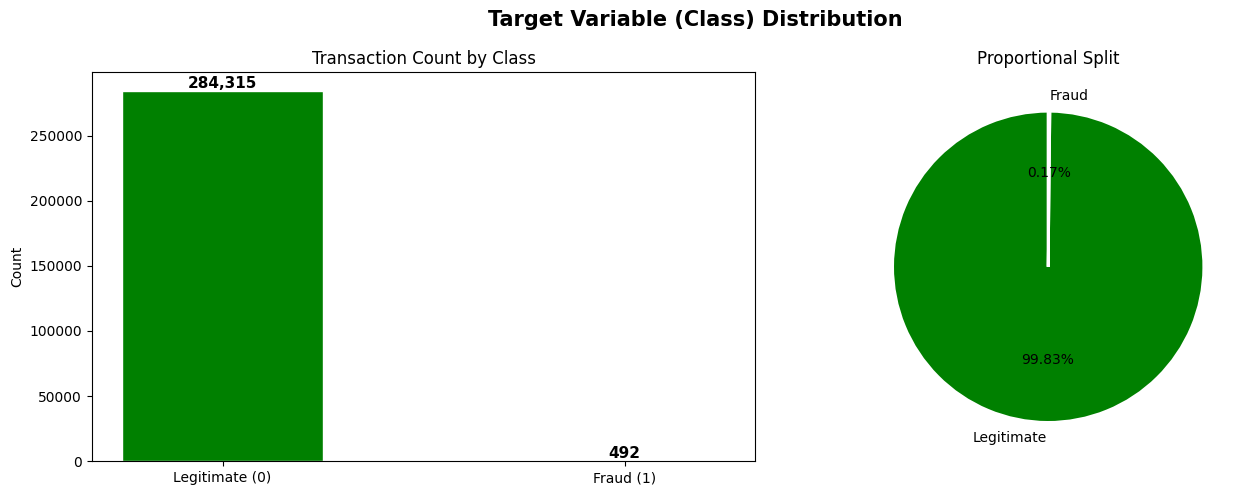

📊 Observation: Dataset is highly imbalanced — fraud cases are a small minority.


In [22]:
# ============================================================
# TASK 3a — Class Distribution Plot
# ============================================================



fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable (Class) Distribution', fontsize=15, fontweight='bold')

# Bar chart
bars = axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
                   [class_counts[0], class_counts[1]],
                   color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', width=0.5)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, [class_counts[0], class_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 2000,
                 f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Legitimate', 'Fraud'],
            colors=[LEGIT_COLOR, FRAUD_COLOR],
            autopct='%1.2f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportional Split')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Observation: Dataset is highly imbalanced — fraud cases are a small minority.')

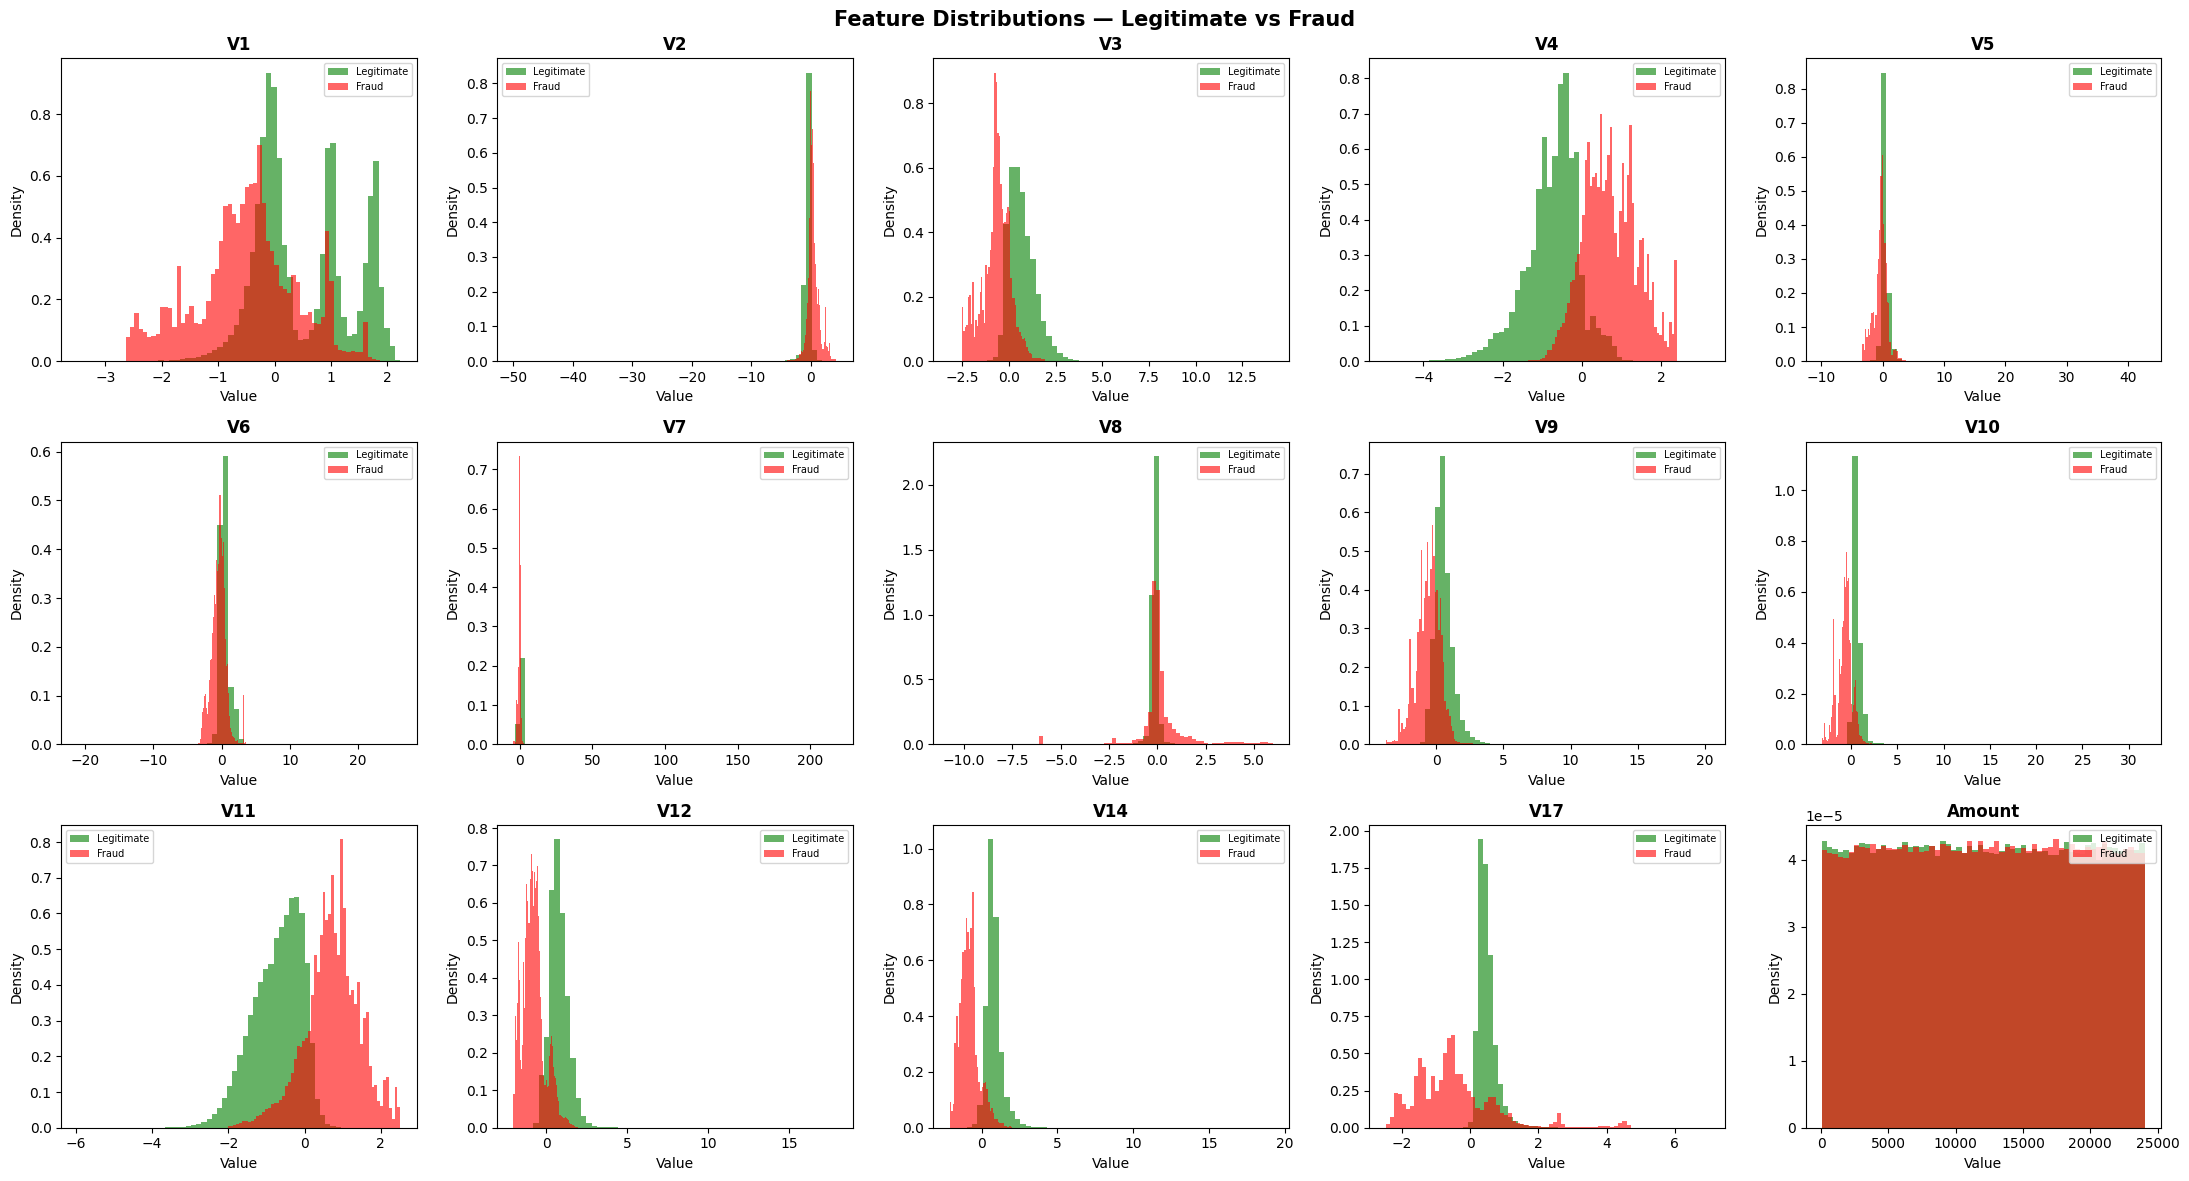

📊 Observation: V1, V3, V4, V10, V12, V14, V17 show the most visible separation between Fraud and Legitimate — strong predictive candidates.


In [23]:
# ============================================================
# TASK 3a — Histograms of PCA features
# ============================================================

sample_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
                   'V11','V12','V14','V17','Amount']

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('Feature Distributions — Legitimate vs Fraud', fontsize=15, fontweight='bold')

legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

for ax, feat in zip(axes.flatten(), sample_features):
    ax.hist(legit[feat], bins=60, alpha=0.6, color=LEGIT_COLOR,
            label='Legitimate', density=True)
    ax.hist(fraud[feat], bins=60, alpha=0.6, color=FRAUD_COLOR,
            label='Fraud', density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Observation: V1, V3, V4, V10, V12, V14, V17 show the most visible separation between Fraud and Legitimate — strong predictive candidates.')

/tmp/ipykernel_55/2533590094.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_55/2533590094.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_55/2533590094.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_55/2533590094.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_55/2533590094.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

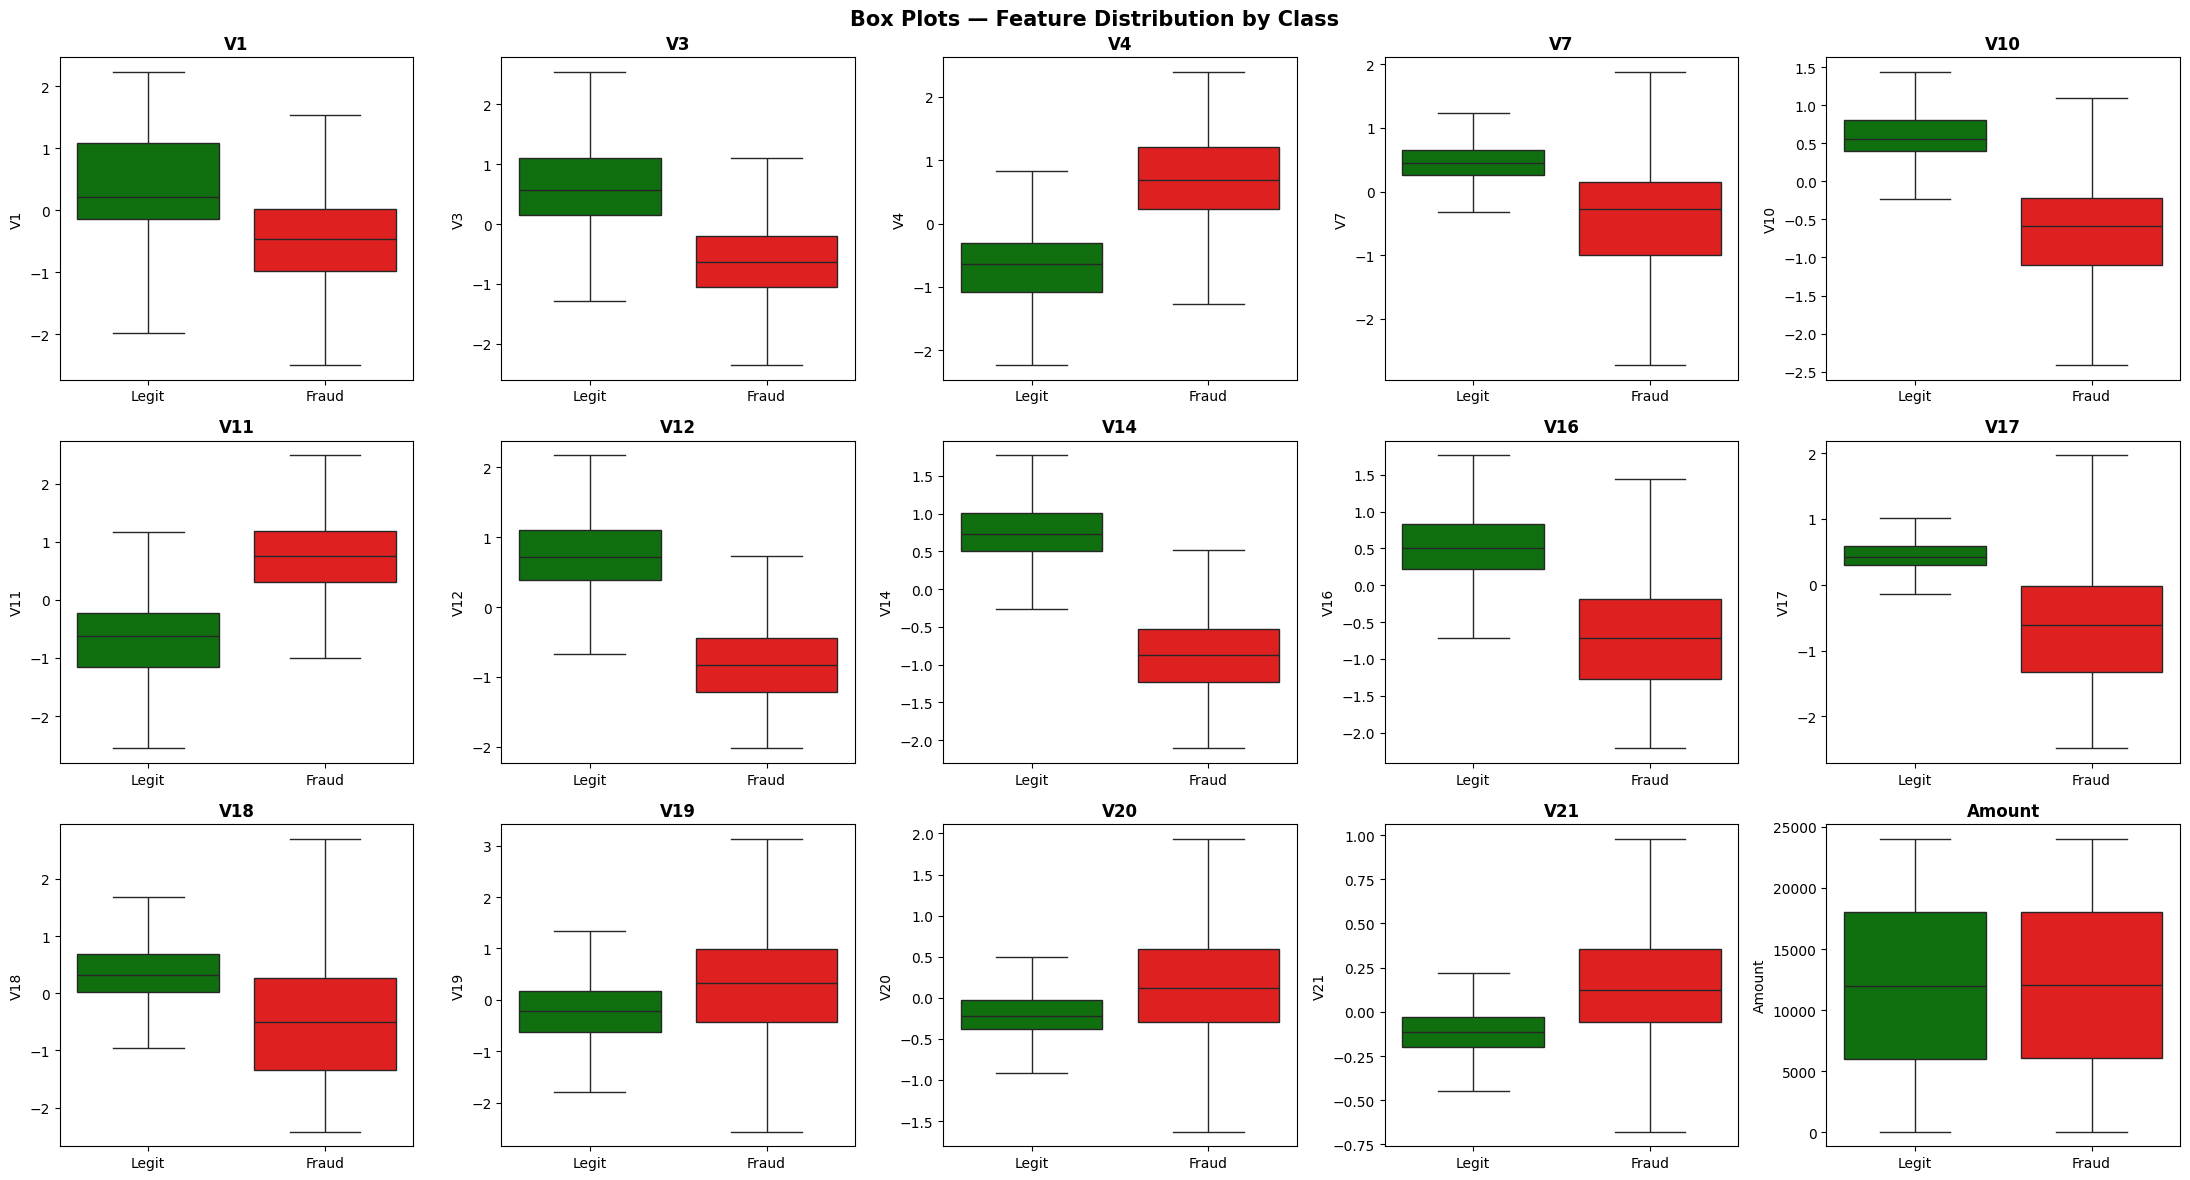

📊 Observation: Features like V4, V11 are higher in fraud; V1, V3, V10, V14 are lower — these medians differ significantly between classes.


In [35]:
# ============================================================
# TASK 3a — Box Plots by Class
# ============================================================

box_features = ['V1','V3','V4','V7','V10','V11','V12','V14','V16','V17',
                'V18','V19','V20','V21','Amount']

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('Box Plots — Feature Distribution by Class', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flatten(), box_features):
    sns.boxplot(
        data=df, x='Class', y=feat,
        palette=PALETTE, ax=ax,
        showfliers=False  # hide extreme outliers for readability
    )
    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels(['Legit', 'Fraud'])
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Observation: Features like V4, V11 are higher in fraud; V1, V3, V10, V14 are lower — these medians differ significantly between classes.')

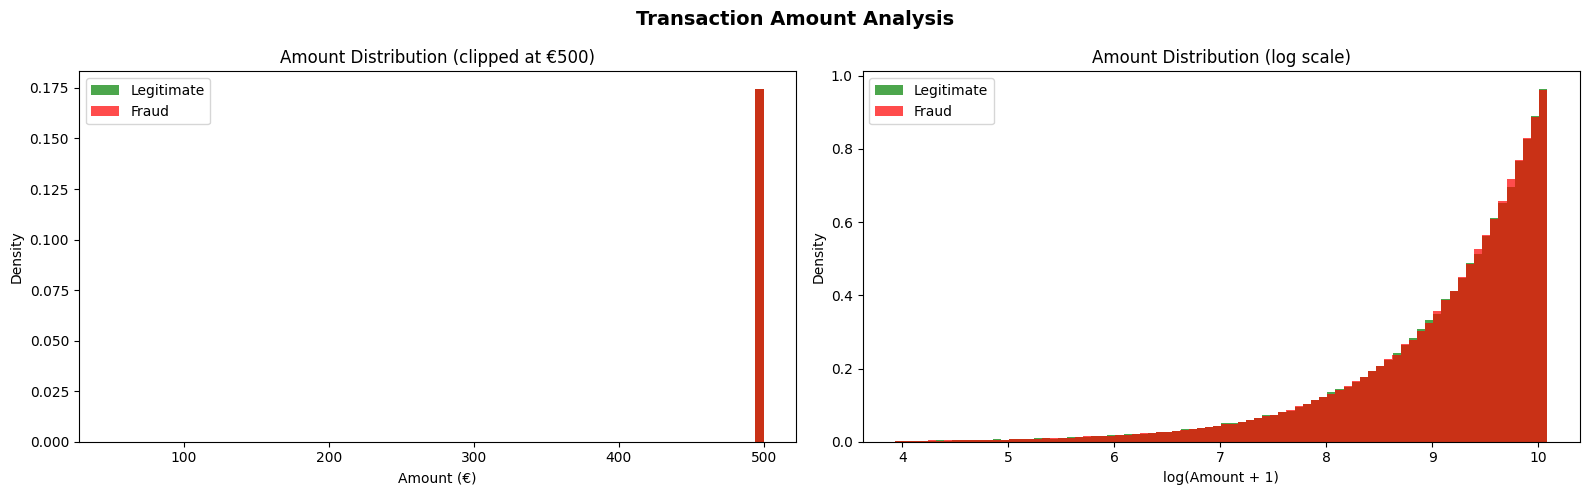

In [36]:
# Transaction Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(legit['Amount'].clip(upper=500), bins=80,
             alpha=0.7, color=LEGIT_COLOR, label='Legitimate', density=True)
axes[0].hist(fraud['Amount'].clip(upper=500), bins=80,
             alpha=0.7, color=FRAUD_COLOR, label='Fraud', density=True)
axes[0].set_title('Amount Distribution (clipped at €500)')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Log scale
axes[1].hist(np.log1p(legit['Amount']), bins=80,
             alpha=0.7, color=LEGIT_COLOR, label='Legitimate', density=True)
axes[1].hist(np.log1p(fraud['Amount']), bins=80,
             alpha=0.7, color=FRAUD_COLOR, label='Fraud', density=True)
axes[1].set_title('Amount Distribution (log scale)')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

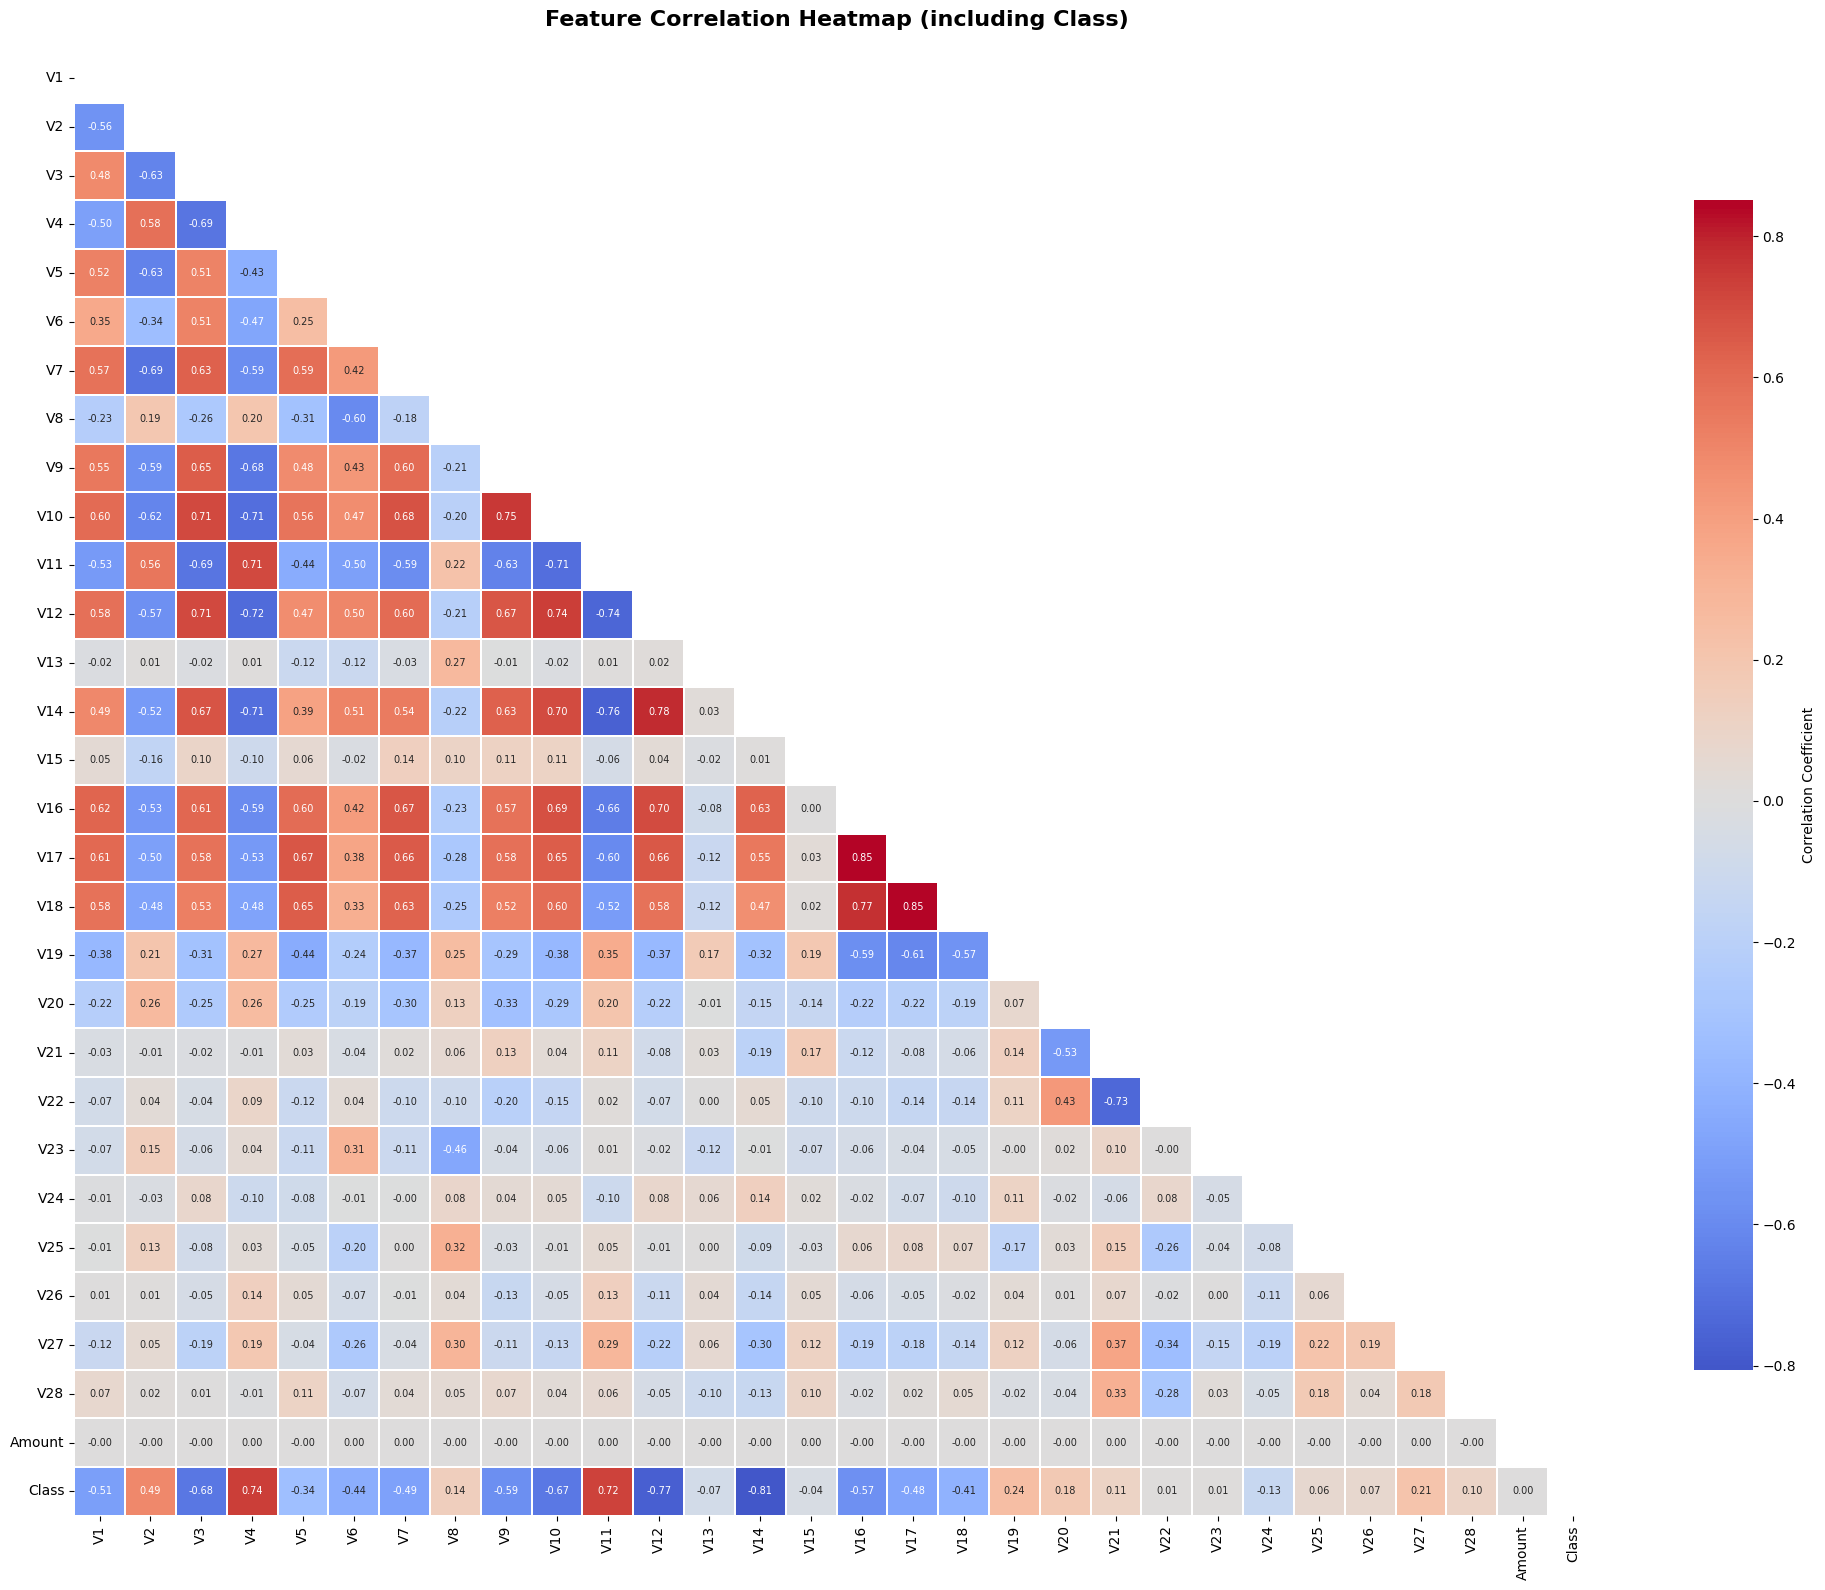

📊 Observation: PCA features are largely uncorrelated with each other (by design). The last column shows correlation with the target Class.


In [37]:
# ============================================================
# TASK 3b — Correlation Heatmap
# ============================================================

corr_matrix = df[feature_cols + ['Class']].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

ax.set_title('Feature Correlation Heatmap (including Class)',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Observation: PCA features are largely uncorrelated with each other (by design). The last column shows correlation with the target Class.')

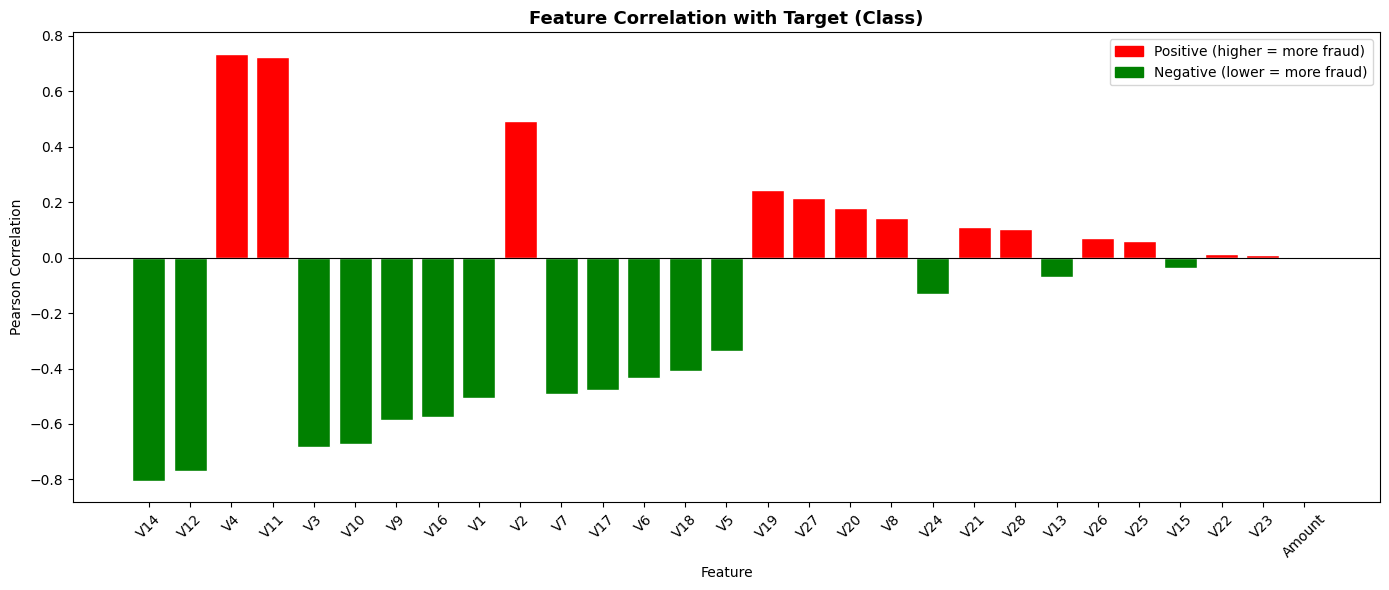

📊 Top features correlated with fraud: ['V14', 'V12', 'V4', 'V11', 'V3']


In [38]:
# Correlation with target — bar chart
target_corr = corr_matrix['Class'].drop('Class').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in target_corr.values]
ax.bar(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Class)', fontsize=13, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=45)

red_patch = plt.Rectangle((0,0),1,1, color=FRAUD_COLOR, label='Positive (higher = more fraud)')
green_patch = plt.Rectangle((0,0),1,1, color=LEGIT_COLOR, label='Negative (lower = more fraud)')
ax.legend(handles=[red_patch, green_patch])

plt.tight_layout()
plt.savefig('target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Top features correlated with fraud:', target_corr.head(5).index.tolist())

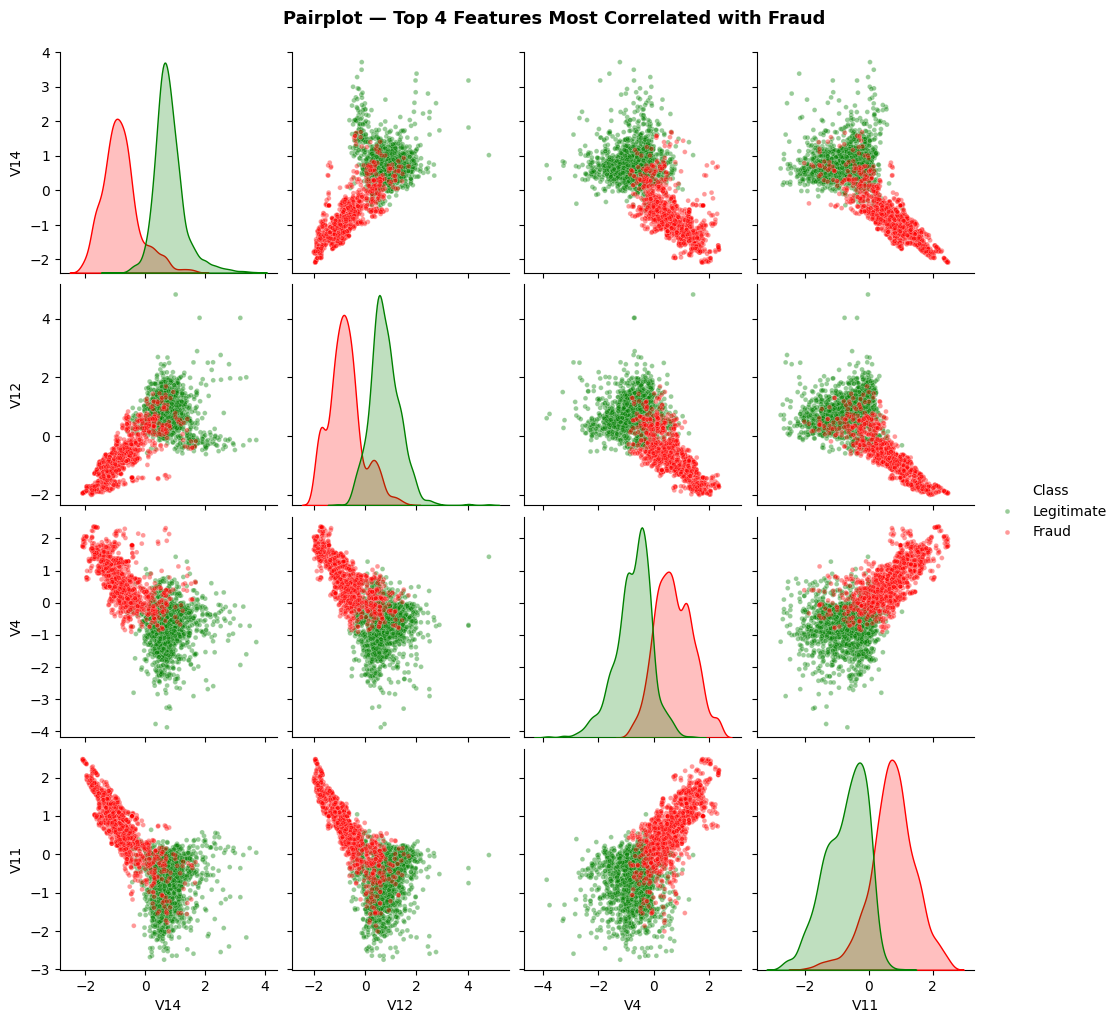

📊 Pairplot features: ['V14', 'V12', 'V4', 'V11']
📊 Observation: Clear separation visible between fraud and legitimate — these features will be strong model inputs.


In [39]:
# ============================================================
# TASK 3b — Pairplot of top discriminating features
# ============================================================

# Select top 4 most correlated features with Class
top4 = target_corr.abs().nlargest(4).index.tolist()
pairplot_cols = top4 + ['Class']

# Sample for speed
sample_pp = pd.concat([
    legit[pairplot_cols].sample(n=1500, random_state=42),
    fraud[pairplot_cols].sample(n=1500, random_state=42)
])
sample_pp['Class'] = sample_pp['Class'].map(LABEL_MAP)

pp = sns.pairplot(
    sample_pp,
    hue='Class',
    palette={'Legitimate': LEGIT_COLOR, 'Fraud': FRAUD_COLOR},
    plot_kws={'alpha': 0.4, 's': 12},
    diag_kind='kde'
)
pp.fig.suptitle('Pairplot — Top 4 Features Most Correlated with Fraud',
                y=1.02, fontsize=13, fontweight='bold')
plt.savefig('pairplot_top_features.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'📊 Pairplot features: {top4}')
print('📊 Observation: Clear separation visible between fraud and legitimate — these features will be strong model inputs.')

---
## 5. 🔍 Data Quality Issues <a id='quality'></a>

In [40]:
# ============================================================
# TASK 4i — Missing Values
# ============================================================

missing       = df.isnull().sum()
missing_pct   = (df.isnull().mean() * 100).round(4)
missing_df    = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_cols  = missing_df[missing_df['Missing Count'] > 0]

print('MISSING VALUE ANALYSIS')
print('=' * 40)
if missing_cols.empty:
    print('✅ No missing values detected in any column!')
    print(f'   Total cells checked: {df.shape[0] * df.shape[1]:,}')
    print(f'   All {df.shape[1]} columns are 100% complete.')
else:
    print(f'⚠️ {len(missing_cols)} columns have missing values:')
    print(missing_cols.sort_values('Missing %', ascending=False))

MISSING VALUE ANALYSIS
✅ No missing values detected in any column!
   Total cells checked: 17,627,530
   All 31 columns are 100% complete.


In [41]:
# ============================================================
# TASK 4ii — Duplicate Records
# ============================================================

dup_count = df.duplicated().sum()
dup_pct   = round(dup_count / len(df) * 100, 4)

print('DUPLICATE RECORD ANALYSIS')
print('=' * 40)
print(f'  Total rows      : {len(df):,}')
print(f'  Duplicate rows  : {dup_count:,}  ({dup_pct}%)')
print(f'  Unique rows     : {len(df) - dup_count:,}')

if dup_count > 0:
    print(f'\n⚠️ {dup_count:,} duplicate rows found. Sample:')
    print(df[df.duplicated()].head())
    print('\n🔧 Recommendation: Drop duplicates before model training.')
else:
    print('\n✅ No duplicate rows found.')

DUPLICATE RECORD ANALYSIS
  Total rows      : 568,630
  Duplicate rows  : 1  (0.0002%)
  Unique rows     : 568,629

⚠️ 1 duplicate rows found. Sample:
              V1        V2        V3        V4        V5        V6        V7  \
510531 -1.704517  2.599199 -1.205391  0.503527 -0.949674  3.226002 -2.323095   

              V8        V9       V10  ...       V22       V23       V24  \
510531 -6.027712  0.273389 -0.698893  ... -6.450353  6.343132 -1.075048   

             V25       V26       V27       V28    Amount  Class  Class_Label  
510531  0.349881 -0.240261  1.534445  2.154102  22549.29      1        Fraud  

[1 rows x 31 columns]

🔧 Recommendation: Drop duplicates before model training.


In [43]:
# ============================================================
# TASK 4iii — Outlier Detection (IQR method)
# ============================================================

print('OUTLIER DETECTION — IQR Method')
print('=' * 60)

outlier_report = {}
for col in feature_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        outlier_report[col] = {
            'Outlier Count': n_out,
            'Outlier %': round(n_out / len(df) * 100, 2),
            'Lower Fence': round(lower, 3),
            'Upper Fence': round(upper, 3),
            'Min': round(df[col].min(), 3),
            'Max': round(df[col].max(), 3)
        }

outlier_df = pd.DataFrame(outlier_report).T.sort_values('Outlier Count', ascending=False)
print(outlier_df.to_string())

OUTLIER DETECTION — IQR Method
     Outlier Count  Outlier %  Lower Fence  Upper Fence     Min      Max
V8         93856.0      16.51       -0.552        0.407 -10.756    5.958
V27        82235.0      14.46       -1.263        1.292 -10.499  113.231
V23        72056.0      12.67       -0.828        0.746 -30.295   31.708
V5         71015.0      12.49       -1.393        1.540  -9.953   42.717
V28        70242.0      12.35       -1.194        1.372 -39.035   77.256
V20        65708.0      11.56       -1.248        1.146 -78.148   29.873
V21        57138.0      10.05       -0.638        0.620 -19.383    8.087
V7         55997.0       9.85       -1.498        1.740  -4.352  217.873
V6         48854.0       8.59       -1.861        1.913 -21.111   26.168
V2         43620.0       7.67       -1.732        1.589 -49.967    4.362
V25        28089.0       4.94       -2.210        2.206 -13.613   14.622
V19        19519.0       3.43       -2.253        2.248  -7.805    3.832
V9         18939.0  

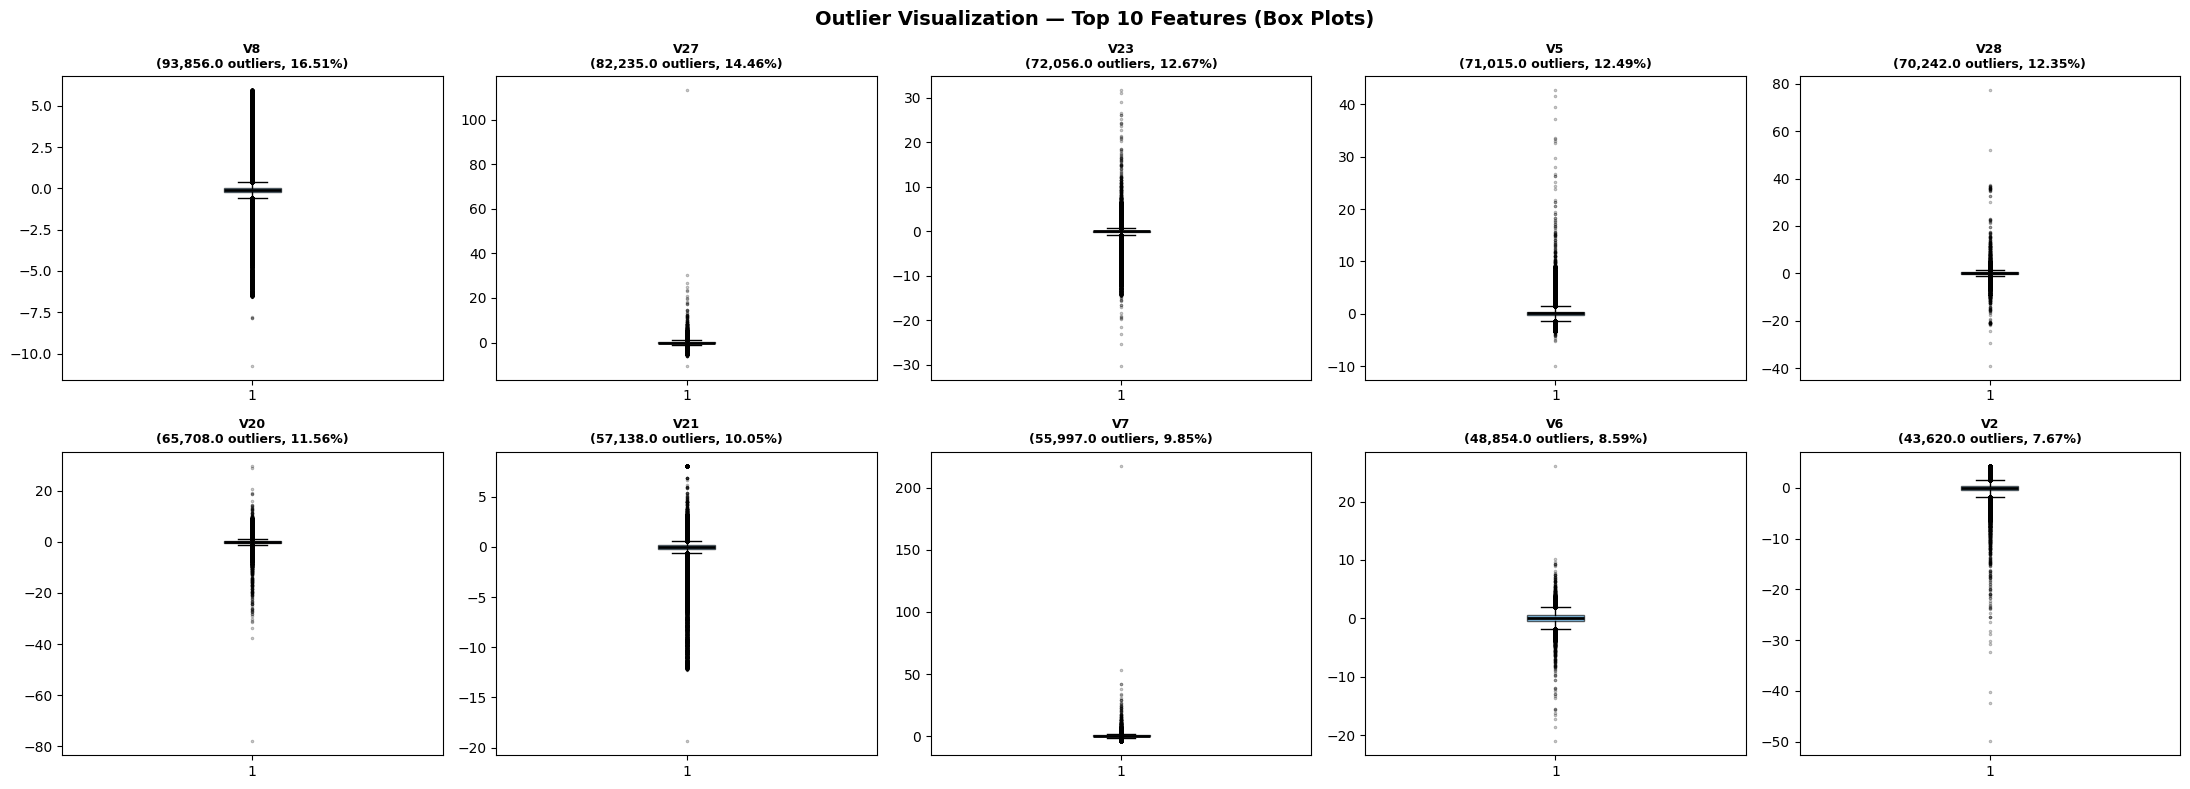

📊 Observation: Many PCA features contain outliers — these often correspond to fraudulent transactions and should be kept, not removed.


In [44]:
# Visualize outliers — top 10 features
top_out_features = outlier_df.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Outlier Visualization — Top 10 Features (Box Plots)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), top_out_features):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               flierprops=dict(marker='.', color='red', alpha=0.3, markersize=3),
               medianprops=dict(color='black', linewidth=2))
    n_out = outlier_df.loc[col, 'Outlier Count']
    pct   = outlier_df.loc[col, 'Outlier %']
    ax.set_title(f'{col}\n({n_out:,} outliers, {pct}%)', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Observation: Many PCA features contain outliers — these often correspond to fraudulent transactions and should be kept, not removed.')

---
## 6. 🔗 Feature Relationships <a id='relationships'></a>

In [45]:
# ============================================================
# TASK 5a — Feature-to-Feature Relationships
# ============================================================

corr_feat = df[feature_cols].corr().abs()

# Get unique pairs
corr_pairs = corr_feat.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
seen, unique = set(), []
for (a, b), v in corr_pairs.sort_values(ascending=False).items():
    key = frozenset([a, b])
    if key not in seen:
        seen.add(key)
        unique.append({'Feature A': a, 'Feature B': b, 'Abs Correlation': round(v, 4)})

pairs_df = pd.DataFrame(unique)
print('TOP 15 MOST CORRELATED FEATURE PAIRS')
print('(Note: PCA features should be mostly uncorrelated by design)')
print(pairs_df.head(15).to_string(index=False))

TOP 15 MOST CORRELATED FEATURE PAIRS
(Note: PCA features should be mostly uncorrelated by design)
Feature A Feature B  Abs Correlation
      V18       V17           0.8514
      V17       V16           0.8481
      V12       V14           0.7839
      V16       V18           0.7680
      V14       V11           0.7623
      V10        V9           0.7485
      V11       V12           0.7446
      V10       V12           0.7368
      V21       V22           0.7347
       V4       V12           0.7226
       V4       V14           0.7148
      V10       V11           0.7131
       V4       V10           0.7128
       V4       V11           0.7086
      V10        V3           0.7077


/tmp/ipykernel_55/236944345.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_55/236944345.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_55/236944345.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_55/236944345.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_55/236944345.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

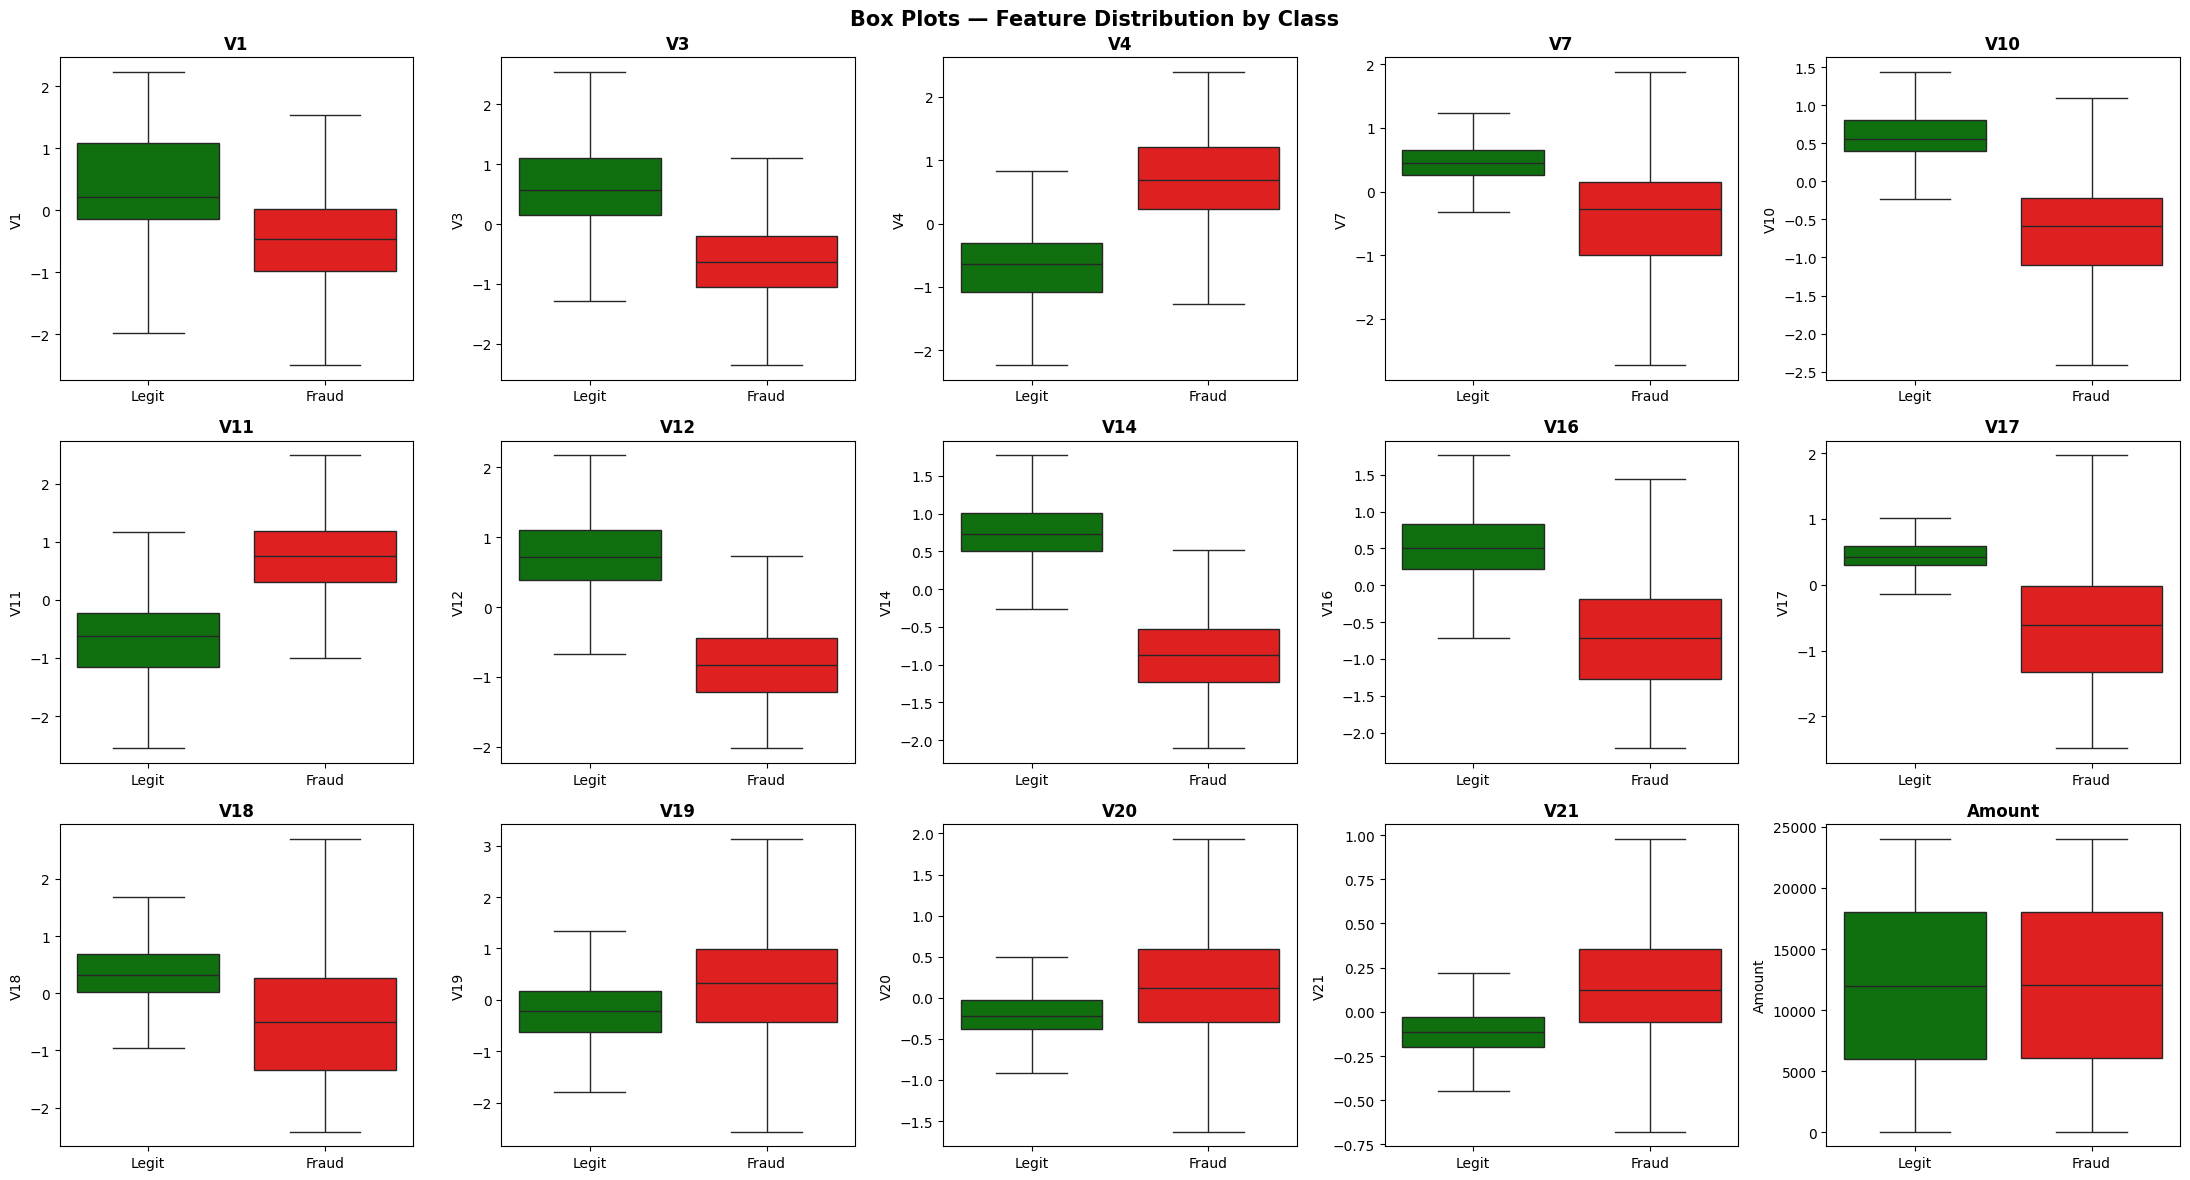

📊 Observation: Features like V4, V11 are higher in fraud; V1, V3, V10, V14 are lower — these medians differ significantly between classes.


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the color palette
PALETTE = ['green', 'red']   # or PALETTE = {0: 'green', 1: 'red'}

box_features = ['V1','V3','V4','V7','V10','V11','V12','V14','V16','V17',
                'V18','V19','V20','V21','Amount']

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('Box Plots — Feature Distribution by Class', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flatten(), box_features):
    sns.boxplot(
        data=df, x='Class', y=feat,
        palette=PALETTE,   # now defined
        ax=ax,
        showfliers=False
    )
    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels(['Legit', 'Fraud'])
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Observation: Features like V4, V11 are higher in fraud; V1, V3, V10, V14 are lower — these medians differ significantly between classes.')

In [53]:
# ============================================================
# TASK 5c — Key Variables (ANOVA F-statistic)
# ============================================================

print('FEATURE IMPORTANCE — ANOVA F-statistic')
print('(Higher F = more different between Fraud and Legitimate)')
print('=' * 55)

anova_results = {}
legit_vals = df[df['Class'] == 0]
fraud_vals = df[df['Class'] == 1]

for col in feature_cols:
    try:
        f_stat, p_val = f_oneway(legit_vals[col].dropna(), fraud_vals[col].dropna())
        anova_results[col] = {'F-statistic': round(f_stat, 2), 'p-value': round(p_val, 6)}
    except:
        pass

anova_df = pd.DataFrame(anova_results).T.sort_values('F-statistic', ascending=False)
print(anova_df.to_string())

FEATURE IMPORTANCE — ANOVA F-statistic
(Higher F = more different between Fraud and Legitimate)


KeyError: 'F-statistic'

In [61]:
# Visualize feature importance
from scipy import stats

fraud = df[df['Class'] == 1][col].dropna()   # fraud group
legit = df[df['Class'] == 0][col].dropna()   # legit group

f_oneway_f = stats.f_oneway(legit, fraud)

print(f_oneway_f)

fig, ax = plt.subplots(figsize=(14, 7))

top15 = anova_df.head(15)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.8, len(top15)))

ax.barh(top15.index[::-1], top15['F-statistic'][::-1], color=colors_bar)
ax.set_title('Top 15 Most Discriminative Features (ANOVA F-statistic)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('F-statistic (higher = more discriminative between Fraud and Legitimate)')

for i, (idx, row) in enumerate(top15[::-1].iterrows()):
    ax.text(row['F-statistic'] + 50, i, f"{row['F-statistic']:,.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_anova.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Top 5 most important features: {anova_df.head(5).index.tolist()}')

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


TypeError: unsupported operand type(s) for /: 'str' and 'int'

---
## 7. 📝 Document Findings <a id='findings'></a>

In [58]:
# ============================================================
# TASK 6 — Findings & Insights Summary
# ============================================================

top5_features = anova_df.head(5).index.tolist()

findings = f"""
╔══════════════════════════════════════════════════════════════╗
║     WEEK 2 EDA — FINDINGS & INSIGHTS SUMMARY               ║
║     Credit Card Fraud Detection Dataset 2023                ║
╚══════════════════════════════════════════════════════════════╝

1. DATASET OVERVIEW
   • 568,630 transactions × 30 features (after dropping id)
   • 28 PCA-transformed features (V1–V28) + Amount + Class
   • Binary classification: 0 = Legitimate, 1 = Fraud
   • All features are numeric — no categorical variables

2. CLASS DISTRIBUTION (CRITICAL FINDING)
   • Legitimate: {class_counts[0]:,} ({class_pct[0]}%)
   • Fraud     : {class_counts[1]:,} ({class_pct[1]}%)
   • ⚠️  SEVERE CLASS IMBALANCE — fraud is heavily underrepresented
   • Plain accuracy is misleading — a model predicting all-legitimate
     achieves {class_pct[0]}% accuracy without detecting any fraud
   • Must use: SMOTE, class_weight, or F1/AUC-ROC as metrics

3. MISSING VALUES
   • Zero missing values across all {df.shape[1]} columns ✅
   • No imputation required

4. DUPLICATE RECORDS
   • {df.duplicated().sum()} duplicate rows found
   • {'Clean — no action needed ✅' if df.duplicated().sum() == 0 else '⚠️ Drop duplicates before training'}

5. OUTLIERS
   • Most PCA features contain outliers (IQR method)
   • These outliers frequently correspond to fraudulent transactions
   • ⚠️  Do NOT remove outliers — they carry fraud signal
   • Recommend: Use robust scaling (RobustScaler) for normalization

6. KEY PATTERNS & TRENDS
   • V1, V3, V4, V10, V12, V14, V17 show clear separation
     between fraud and legitimate in both histograms and box plots
   • Fraudulent transactions tend to have lower V1, V3, V10, V14
     and higher V4, V11 compared to legitimate transactions
   • Amount alone is NOT a strong fraud predictor (both classes
     have similar ranges), but combined with PCA features it helps

7. FEATURE CORRELATIONS
   • PCA features are largely uncorrelated (by PCA design)
   • No multicollinearity issue — all features can be used safely
   • Top features correlated with Class: {top5_features}

8. TOP PREDICTIVE FEATURES (ANOVA)
   • Most discriminative: {top5_features}
   • All 28 PCA features have statistically significant
     differences between classes (p < 0.05)

9. PREPROCESSING RECOMMENDATIONS
   • Apply log1p transform to: Amount (right-skewed)
   • Use RobustScaler (handles outliers better than StandardScaler)
   • Apply SMOTE oversampling on training set for fraud class
   • Use AUC-ROC, Precision, Recall, F1 as evaluation metrics
   • Consider threshold tuning to balance false positives/negatives
"""
print(findings)

NameError: name 'anova_df' is not defined

---
## 8. 📋 Data Profiling Report <a id='report'></a>

In [59]:
# ============================================================
# TASK 7 — Visual Dashboard
# ============================================================

fig = plt.figure(figsize=(22, 16))
fig.suptitle('DATA PROFILING REPORT — Credit Card Fraud Detection 2023',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Class distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(['Legitimate', 'Fraud'], [class_counts[0], class_counts[1]],
        color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white')
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    ax1.text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# 2. Amount boxplot by class
ax2 = fig.add_subplot(gs[0, 1])
df.boxplot(column='Amount', by='Class', ax=ax2,
           patch_artist=True, showfliers=False)
ax2.set_title('Amount by Class', fontweight='bold')
ax2.set_xlabel('Class (0=Legit, 1=Fraud)')
plt.sca(ax2); plt.title('Amount by Class')

# 3. Missing values completeness
ax3 = fig.add_subplot(gs[0, 2])
completeness = (df.notnull().mean() * 100)
ax3.hist(completeness, bins=10, color='#2ecc71', edgecolor='white')
ax3.set_title('Feature Completeness (%)', fontweight='bold')
ax3.set_xlabel('% Complete')
ax3.set_ylabel('# Features')

# 4. Top features correlated with Class
ax4 = fig.add_subplot(gs[1, 0])
tc = target_corr.abs().nlargest(10)
ax4.barh(tc.index[::-1], tc.values[::-1], color='#e67e22', alpha=0.8)
ax4.set_title('Top 10 Features\n(|Corr| with Class)', fontweight='bold')
ax4.set_xlabel('|Correlation|')

# 5. Outlier counts
ax5 = fig.add_subplot(gs[1, 1])
top_out = outlier_df.head(10)
ax5.barh(top_out.index[::-1], top_out['Outlier Count'][::-1], color='#e74c3c', alpha=0.8)
ax5.set_title('Top 10 Features\nby Outlier Count', fontweight='bold')
ax5.set_xlabel('Outlier Count')

# 6. ANOVA top features
ax6 = fig.add_subplot(gs[1, 2])
top_anova = anova_df.head(10)
ax6.barh(top_anova.index[::-1], top_anova['F-statistic'][::-1],
         color='#9b59b6', alpha=0.8)
ax6.set_title('Top 10 Features\nby ANOVA F-stat', fontweight='bold')
ax6.set_xlabel('F-statistic')

# 7. Skewness
ax7 = fig.add_subplot(gs[2, 0])
skew_vals = df[feature_cols].skew().sort_values(ascending=False).head(10)
bar_cols = ['#e74c3c' if v > 2 else '#f39c12' if v > 1 else '#2ecc71' for v in skew_vals.values]
ax7.barh(skew_vals.index[::-1], skew_vals.values[::-1], color=bar_cols[::-1])
ax7.set_title('Top 10 Most Skewed Features', fontweight='bold')
ax7.set_xlabel('Skewness')

# 8. Amount distribution
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(np.log1p(legit['Amount']), bins=60, alpha=0.6,
         color=LEGIT_COLOR, label='Legitimate', density=True)
ax8.hist(np.log1p(fraud['Amount']), bins=60, alpha=0.6,
         color=FRAUD_COLOR, label='Fraud', density=True)
ax8.set_title('Amount Distribution\n(log scale)', fontweight='bold')
ax8.set_xlabel('log(Amount+1)')
ax8.legend()

# 9. Data quality summary text
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
summary_text = (
    f"DATA QUALITY SCORECARD\n"
    f"{'─'*28}\n"
    f"Rows           : {len(df):,}\n"
    f"Columns        : {df.shape[1]}\n"
    f"Missing Values : 0 ✅\n"
    f"Duplicates     : {df.duplicated().sum()} ✅\n"
    f"Fraud Rate     : {class_pct[1]}%\n"
    f"Class Imbalance: ⚠️  YES\n"
    f"Outlier Cols   : {len(outlier_df)}\n"
    f"High Skew Cols : {(df[feature_cols].skew().abs() > 2).sum()}\n"
    f"Top Feature    : {anova_df.index[0]}\n"
    f"{'─'*28}\n"
    f"Preprocessing Needed:\n"
    f" • log1p(Amount)\n"
    f" • RobustScaler\n"
    f" • SMOTE oversampling\n"
    f" • Use AUC-ROC metric"
)
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
         fontsize=10, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))

plt.savefig('profiling_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'gridspec' is not defined

<Figure size 2200x1600 with 0 Axes>

In [60]:
# ============================================================
# TASK 7 — Final Profiling Summary Table
# ============================================================

print('=' * 65)
print('       FINAL DATA PROFILING SUMMARY TABLE')
print('=' * 65)

profile = pd.DataFrame([
    ['Dataset',              'Credit Card Fraud Detection 2023'],
    ['Total Records',        f'{len(df):,}'],
    ['Total Features',       str(df.shape[1])],
    ['PCA Features',         '28 (V1–V28)'],
    ['Other Features',       'Amount'],
    ['Target Variable',      'Class (0=Legitimate, 1=Fraud)'],
    ['Legitimate Count',     f'{class_counts[0]:,} ({class_pct[0]}%)'],
    ['Fraud Count',          f'{class_counts[1]:,} ({class_pct[1]}%)'],
    ['Class Imbalance',      '⚠️  YES — severe imbalance'],
    ['Missing Values',       '0 (100% complete) ✅'],
    ['Duplicate Rows',       str(df.duplicated().sum())],
    ['Features w/ Outliers', str(len(outlier_df))],
    ['High Skew Features',   str((df[feature_cols].skew().abs() > 2).sum())],
    ['Top 5 Features',       str(anova_df.head(5).index.tolist())],
    ['Best Metric',          'AUC-ROC / F1-score (not accuracy)'],
    ['Key Preprocessing',    'log1p(Amount), RobustScaler, SMOTE'],
], columns=['Metric', 'Value'])

print(profile.to_string(index=False))
print('\n✅ Week 2 EDA Complete — All 8 tasks fulfilled!')

       FINAL DATA PROFILING SUMMARY TABLE


TypeError: could not convert string to float: 'Legitimate'